## Set Up

In [1]:
# ============================================================
# Time Series Classification - Clean Notebook
# Subject-level split, no data leakage
# ============================================================

import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit

try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
except ImportError:
    HAS_STRATIFIED_GROUP_KFOLD = False

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

warnings.filterwarnings("ignore")

random_state = 42

# Change this only if your folder structure is different
DATASET_DIR = "../dataset/"

preprocessed_path = os.path.join(DATASET_DIR, "CMI_timeseries_preprocessed_outputs.pkl")
approximation_path = os.path.join(DATASET_DIR, "CMI_timeseries_approximation_outputs.pkl")
metadata_path = os.path.join(DATASET_DIR, "CMI_timeseries_metadata_filtered.pkl")

In [2]:
# ============================================================
# Load prepared objects
# ============================================================

for path in [preprocessed_path, approximation_path, metadata_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")

with open(preprocessed_path, "rb") as f:
    preprocessed_outputs = pickle.load(f)

with open(approximation_path, "rb") as f:
    approximation_outputs = pickle.load(f)

metadata_df = pd.read_pickle(metadata_path)

print("Preprocessed output keys:")
print(preprocessed_outputs.keys())

print("\nApproximation output keys:")
print(approximation_outputs.keys())

print("\nMetadata shape:", metadata_df.shape)
display(metadata_df.head())

print("\nMetadata columns:")
print(metadata_df.columns.tolist())

print("\nTarget distribution:")
display(metadata_df["target"].value_counts().sort_index())

print("\nNumber of subjects:", metadata_df["subject_id"].nunique())

Preprocessed output keys:
dict_keys(['CMI_timeseries_preprocessed', 'CMI_timeseries_global_scaled', 'CMI_timeseries_subject_scaled', 'signal_cols', 'id_col', 'target_col', 'target_df', 'filtered_target_df', 'non_wear_df', 'hampel_summary_df'])

Approximation output keys:
dict_keys(['X_paa_global', 'X_paa_subject', 'sax_df', 'signal_cols', 'id_col', 'target_col', 'n_segments', 'alphabet_size', 'signal_to_sax'])

Metadata shape: (4310, 3)


,window_pos,subject_id,target
0,0,2265,0
1,1,3042,1
2,2,1647,1
3,3,736,0
4,4,1044,0



Metadata columns:
['window_pos', 'subject_id', 'target']

Target distribution:


target
0    2888
1    1422
Name: count, dtype: int64


Number of subjects: 375


In [3]:
# ============================================================
# Prepare X, y, and groups
# ============================================================

X_ts = approximation_outputs["X_paa_subject"].copy()

y = metadata_df["target"].to_numpy()
groups = metadata_df["subject_id"].to_numpy()

print("X_ts shape:", X_ts.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)

assert X_ts.ndim == 3, (
    "Expected X_ts with shape: n_instances × n_timepoints × n_channels."
)

assert X_ts.shape[0] == len(y) == len(groups), (
    "Mismatch: X_ts, y, and groups must have the same number of rows."
)

n_instances, n_timepoints, n_channels = X_ts.shape

print("\nNumber of time series/windows:", n_instances)
print("Number of time points:", n_timepoints)
print("Number of channels:", n_channels)
print("Number of unique subjects:", len(np.unique(groups)))

X_ts shape: (4310, 50, 6)
y shape: (4310,)
groups shape: (4310,)

Number of time series/windows: 4310
Number of time points: 50
Number of channels: 6
Number of unique subjects: 375


In [4]:
# ============================================================
# Subject-level train/test split
# NO subject can appear in both train and test
# ============================================================

test_size = 0.25

if HAS_STRATIFIED_GROUP_KFOLD:
    # 4 folds gives approximately 25% test size.
    splitter = StratifiedGroupKFold(
        n_splits=4,
        shuffle=True,
        random_state=random_state
    )

    train_idx, test_idx = next(splitter.split(X_ts, y, groups=groups))

    split_method = "StratifiedGroupKFold"

else:
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=random_state
    )

    train_idx, test_idx = next(splitter.split(X_ts, y, groups=groups))

    split_method = "GroupShuffleSplit"

X_train_ts_raw = X_ts[train_idx]
X_test_ts_raw = X_ts[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

groups_train = groups[train_idx]
groups_test = groups[test_idx]

print("Split method:", split_method)

print("\nTrain shape:", X_train_ts_raw.shape)
print("Test shape:", X_test_ts_raw.shape)

print("\nTrain target distribution:")
display(pd.Series(y_train).value_counts().sort_index())

print("\nTest target distribution:")
display(pd.Series(y_test).value_counts().sort_index())

print("\nTrain subjects:", len(np.unique(groups_train)))
print("Test subjects:", len(np.unique(groups_test)))

overlap_subjects = set(groups_train).intersection(set(groups_test))

print("Subject overlap:", len(overlap_subjects))

assert len(overlap_subjects) == 0, (
    f"DATA LEAKAGE: {len(overlap_subjects)} subjects appear in both train and test."
)

subject_split_check = pd.DataFrame({
    "subject_id": np.concatenate([groups_train, groups_test]),
    "split": ["train"] * len(groups_train) + ["test"] * len(groups_test)
})

bad_subjects = (
    subject_split_check
    .groupby("subject_id")["split"]
    .nunique()
)

bad_subjects = bad_subjects[bad_subjects > 1]

assert bad_subjects.empty, (
    "DATA LEAKAGE: at least one subject has time series/windows in both train and test."
)

print("\nNo subject-level leakage detected.")

Split method: StratifiedGroupKFold

Train shape: (3220, 50, 6)
Test shape: (1090, 50, 6)

Train target distribution:


0    2152
1    1068
Name: count, dtype: int64


Test target distribution:


0    736
1    354
Name: count, dtype: int64


Train subjects: 281
Test subjects: 94
Subject overlap: 0

No subject-level leakage detected.


In [5]:
# ============================================================
# Train-only imputation for non-finite values
# ============================================================

def impute_non_finite_3d_train_only(X_train, X_test):
    """
    Replace NaN/inf values using channel-wise medians computed only on train.

    Input shape:
        n_instances × n_timepoints × n_channels
    """

    X_train = X_train.astype(float).copy()
    X_test = X_test.astype(float).copy()

    X_train_for_median = np.where(np.isfinite(X_train), X_train, np.nan)

    channel_medians = np.nanmedian(X_train_for_median, axis=(0, 1))
    channel_medians = np.where(np.isfinite(channel_medians), channel_medians, 0.0)

    for j in range(X_train.shape[2]):
        train_bad = ~np.isfinite(X_train[:, :, j])
        test_bad = ~np.isfinite(X_test[:, :, j])

        X_train[:, :, j][train_bad] = channel_medians[j]
        X_test[:, :, j][test_bad] = channel_medians[j]

    return X_train, X_test, channel_medians


X_train_ts, X_test_ts, train_channel_medians = impute_non_finite_3d_train_only(
    X_train_ts_raw,
    X_test_ts_raw
)

print("Train channel medians used for imputation:")
print(train_channel_medians)

assert np.isfinite(X_train_ts).all(), "Non-finite values remain in train."
assert np.isfinite(X_test_ts).all(), "Non-finite values remain in test."

print("No non-finite values detected after train-only imputation.")

Train channel medians used for imputation:
[-0.0577457   0.00188867  0.00140162 -0.2254605   0.00658018 -0.24773937]
No non-finite values detected after train-only imputation.


## KNN

In [6]:
# ============================================================
# Flatten time series for Euclidean KNN
# ============================================================

X_train_flat = X_train_ts.reshape(X_train_ts.shape[0], -1)
X_test_flat = X_test_ts.reshape(X_test_ts.shape[0], -1)

print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape:", X_test_flat.shape)

X_train_flat shape: (3220, 300)
X_test_flat shape: (1090, 300)


In [7]:
# ============================================================
# Reusable classifier evaluation function
# ============================================================

def get_score_for_auc(model, X_test):
    """
    Return score/probabilities suitable for ROC-AUC when possible.
    Works for binary and multiclass classifiers.
    """

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)

        if proba.ndim == 2 and proba.shape[1] == 2:
            # Positive class is assumed to be 1 if present.
            if 1 in model.classes_:
                positive_index = list(model.classes_).index(1)
            else:
                positive_index = 1

            return proba[:, positive_index]

        return proba

    if hasattr(model, "decision_function"):
        return model.decision_function(X_test)

    return None


def evaluate_classifier(model_name, y_true, y_pred, y_score=None, show_confusion_matrix=True):
    """
    Evaluate a classifier using standard classification metrics.
    Supports binary and multiclass settings.
    """

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

    if y_score is not None:
        try:
            unique_classes = np.unique(y_true)

            if len(unique_classes) == 2:
                results["roc_auc"] = roc_auc_score(y_true, y_score)
            else:
                results["roc_auc"] = roc_auc_score(
                    y_true,
                    y_score,
                    multi_class="ovr",
                    average="macro"
                )

        except Exception:
            results["roc_auc"] = np.nan
    else:
        results["roc_auc"] = np.nan

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    print(classification_report(y_true, y_pred, zero_division=0))

    if show_confusion_matrix:
        labels = np.unique(np.concatenate([np.asarray(y_true), np.asarray(y_pred)]))
        cm = confusion_matrix(y_true, y_pred, labels=labels)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=labels
        )

        disp.plot(values_format="d")
        plt.title(model_name)
        plt.tight_layout()
        plt.show()

    return results

In [9]:
# ============================================================
# KNN GRID SEARCH - Euclidean + 1NN DTW
# NO DATA LEAKAGE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

try:
    from tslearn.neighbors import KNeighborsTimeSeriesClassifier
except ImportError:
    raise ImportError(
        "tslearn is not installed. Install it with:\n\n"
        "pip install tslearn\n"
    )

random_state = 42

In [10]:
# ============================================================
# Strong leakage check: train/test subjects must be disjoint
# ============================================================

train_subjects = set(groups_train)
test_subjects = set(groups_test)

overlap_subjects = train_subjects.intersection(test_subjects)

print("Train subjects:", len(train_subjects))
print("Test subjects:", len(test_subjects))
print("Subject overlap:", len(overlap_subjects))

assert len(overlap_subjects) == 0, (
    f"DATA LEAKAGE: {len(overlap_subjects)} subjects appear in both train and test."
)

assert X_train_ts.shape[0] == len(y_train) == len(groups_train)
assert X_test_ts.shape[0] == len(y_test) == len(groups_test)

print("No subject-level train/test leakage detected.")

Train subjects: 281
Test subjects: 94
Subject overlap: 0
No subject-level train/test leakage detected.


In [11]:
# ============================================================
# Evaluation utilities
# ============================================================

def get_score_for_auc(model, X):
    """
    Get probabilities/scores for ROC-AUC when available.
    """

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)

        if proba.ndim == 2 and proba.shape[1] == 2:
            classes = list(model.classes_)

            if 1 in classes:
                positive_index = classes.index(1)
            else:
                positive_index = 1

            return proba[:, positive_index]

        return proba

    if hasattr(model, "decision_function"):
        return model.decision_function(X)

    return None


def evaluate_classifier(model_name, y_true, y_pred, y_score=None, show_confusion_matrix=True):
    """
    Print and return evaluation metrics.
    """

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

    if y_score is not None:
        try:
            if len(np.unique(y_true)) == 2:
                results["roc_auc"] = roc_auc_score(y_true, y_score)
            else:
                results["roc_auc"] = roc_auc_score(
                    y_true,
                    y_score,
                    multi_class="ovr",
                    average="macro"
                )
        except Exception:
            results["roc_auc"] = np.nan
    else:
        results["roc_auc"] = np.nan

    print("\n" + "=" * 90)
    print(model_name)
    print("=" * 90)

    print(classification_report(y_true, y_pred, zero_division=0))

    print("Accuracy:", results["accuracy"])
    print("Balanced accuracy:", results["balanced_accuracy"])
    print("F1 macro:", results["f1_macro"])
    print("F1 weighted:", results["f1_weighted"])
    print("ROC-AUC:", results["roc_auc"])

    if show_confusion_matrix:
        labels = np.unique(np.concatenate([np.asarray(y_true), np.asarray(y_pred)]))
        cm = confusion_matrix(y_true, y_pred, labels=labels)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=labels
        )

        disp.plot(values_format="d")
        plt.title(model_name)
        plt.tight_layout()
        plt.show()

    return results

In [12]:
# ============================================================
# Helper functions for CV evaluation
# ============================================================

def make_euclidean_knn(n_neighbors, weights):
    """
    Euclidean KNN on flattened time series.
    StandardScaler is fitted only inside each train fold.
    """

    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "classifier",
                KNeighborsClassifier(
                    n_neighbors=n_neighbors,
                    metric="euclidean",
                    weights=weights
                )
            )
        ]
    )


def make_dtw_knn(n_neighbors=1):
    """
    1NN DTW on 3D time series.
    """

    base_model = KNeighborsTimeSeriesClassifier()
    available_params = base_model.get_params().keys()

    params = {
        "n_neighbors": n_neighbors,
        "metric": "dtw",
        "weights": "uniform"
    }

    if "n_jobs" in available_params:
        params["n_jobs"] = -1

    return KNeighborsTimeSeriesClassifier(**params)


def flatten_ts(X):
    """
    Convert 3D time series to 2D feature matrix for Euclidean KNN.
    """

    return X.reshape(X.shape[0], -1)

In [13]:
# ============================================================
# Grid definition
# ============================================================

euclidean_param_grid = [
    {
        "method": "euclidean",
        "n_neighbors": k,
        "weights": weights
    }
    for k in [1, 3, 5, 7, 9, 11, 15]
    for weights in ["uniform", "distance"]
]

# For DTW the professor asks DTW. We keep it as 1NN DTW.
dtw_param_grid = [
    {
        "method": "dtw",
        "n_neighbors": 1,
        "weights": "uniform"
    }
]

full_knn_grid = euclidean_param_grid + dtw_param_grid

print("Number of KNN configurations:", len(full_knn_grid))
print("Euclidean configurations:", len(euclidean_param_grid))
print("DTW configurations:", len(dtw_param_grid))

Number of KNN configurations: 15
Euclidean configurations: 14
DTW configurations: 1


In [14]:
# ============================================================
# Leakage-safe CV grid search
# Model selection uses TRAIN only.
# Test set is untouched.
# ============================================================

n_unique_train_subjects = len(np.unique(groups_train))
n_splits = min(5, n_unique_train_subjects)

if n_splits < 2:
    raise ValueError("Not enough training subjects for group cross-validation.")

cv = StratifiedGroupKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=random_state
)

grid_results = []

print("Starting leakage-safe KNN grid search...")
print("CV folds:", n_splits)

for config in full_knn_grid:
    fold_scores = []

    for fold_id, (inner_train_idx, inner_val_idx) in enumerate(
        cv.split(X_train_ts, y_train, groups=groups_train)
    ):
        inner_train_subjects = set(groups_train[inner_train_idx])
        inner_val_subjects = set(groups_train[inner_val_idx])

        assert len(inner_train_subjects.intersection(inner_val_subjects)) == 0, (
            "DATA LEAKAGE inside CV: a subject appears in both inner train and validation."
        )

        X_inner_train = X_train_ts[inner_train_idx]
        X_inner_val = X_train_ts[inner_val_idx]

        y_inner_train = y_train[inner_train_idx]
        y_inner_val = y_train[inner_val_idx]

        if config["method"] == "euclidean":
            X_inner_train_model = flatten_ts(X_inner_train)
            X_inner_val_model = flatten_ts(X_inner_val)

            model = make_euclidean_knn(
                n_neighbors=config["n_neighbors"],
                weights=config["weights"]
            )

            model.fit(X_inner_train_model, y_inner_train)
            y_inner_pred = model.predict(X_inner_val_model)

        elif config["method"] == "dtw":
            model = make_dtw_knn(
                n_neighbors=config["n_neighbors"]
            )

            model.fit(X_inner_train, y_inner_train)
            y_inner_pred = model.predict(X_inner_val)

        else:
            raise ValueError(f"Unknown method: {config['method']}")

        fold_score = balanced_accuracy_score(y_inner_val, y_inner_pred)
        fold_scores.append(fold_score)

    result = {
        **config,
        "cv_balanced_accuracy_mean": float(np.mean(fold_scores)),
        "cv_balanced_accuracy_std": float(np.std(fold_scores)),
        "cv_fold_scores": fold_scores
    }

    grid_results.append(result)

grid_results_df = pd.DataFrame(grid_results)

best_config = (
    grid_results_df
    .sort_values(
        ["cv_balanced_accuracy_mean", "cv_balanced_accuracy_std"],
        ascending=[False, True]
    )
    .iloc[0]
    .to_dict()
)

print("\nBest KNN configuration selected by CV balanced accuracy:")
print(best_config)

Starting leakage-safe KNN grid search...
CV folds: 5

Best KNN configuration selected by CV balanced accuracy:
{'method': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform', 'cv_balanced_accuracy_mean': 0.5180147449994724, 'cv_balanced_accuracy_std': 0.02335223424920849, 'cv_fold_scores': [np.float64(0.5356586224233283), np.float64(0.48516483516483516), np.float64(0.4946000760552668), np.float64(0.5327324261310821), np.float64(0.54191776522285)]}


Refitting best model on full training set...
Predicting test set...

Best KNN overall: Euclidean k=5, weights=uniform
              precision    recall  f1-score   support

           0       0.67      0.79      0.73       736
           1       0.31      0.20      0.24       354

    accuracy                           0.60      1090
   macro avg       0.49      0.49      0.48      1090
weighted avg       0.56      0.60      0.57      1090

Accuracy: 0.5981651376146789
Balanced accuracy: 0.4942504912797838
F1 macro: 0.48440314658579886
F1 weighted: 0.5692802570800023
ROC-AUC: 0.4963518637926799


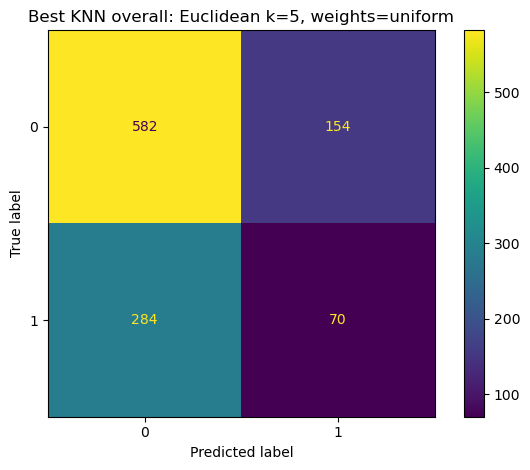

,model,distance,n_neighbors,weights,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc,leakage_control
0,"Best KNN overall: Euclidean k=5, weights=uniform",euclidean,5,uniform,0.518015,0.023352,0.598165,0.49425,0.492278,0.49425,0.484403,0.56928,0.496352,subject-level train/test split; grouped CV on ...


In [15]:
# ============================================================
# Refit ONLY the best model on the full training set
# Then evaluate once on the test set
# ============================================================

if best_config["method"] == "euclidean":
    final_knn_model = make_euclidean_knn(
        n_neighbors=int(best_config["n_neighbors"]),
        weights=best_config["weights"]
    )

    X_train_final = flatten_ts(X_train_ts)
    X_test_final = flatten_ts(X_test_ts)

    final_model_name = (
        f"Best KNN overall: Euclidean "
        f"k={int(best_config['n_neighbors'])}, "
        f"weights={best_config['weights']}"
    )

elif best_config["method"] == "dtw":
    final_knn_model = make_dtw_knn(
        n_neighbors=int(best_config["n_neighbors"])
    )

    X_train_final = X_train_ts
    X_test_final = X_test_ts

    final_model_name = "Best KNN overall: 1NN DTW"

else:
    raise ValueError(f"Unknown method: {best_config['method']}")

print("Refitting best model on full training set...")
final_knn_model.fit(X_train_final, y_train)

print("Predicting test set...")
y_pred_best_knn = final_knn_model.predict(X_test_final)

try:
    y_score_best_knn = get_score_for_auc(final_knn_model, X_test_final)
except Exception:
    y_score_best_knn = None

best_knn_result = evaluate_classifier(
    model_name=final_model_name,
    y_true=y_test,
    y_pred=y_pred_best_knn,
    y_score=y_score_best_knn,
    show_confusion_matrix=True
)

best_knn_result["method_family"] = "KNN"
best_knn_result["distance"] = best_config["method"]
best_knn_result["n_neighbors"] = int(best_config["n_neighbors"])
best_knn_result["weights"] = best_config["weights"]
best_knn_result["cv_balanced_accuracy_mean"] = best_config["cv_balanced_accuracy_mean"]
best_knn_result["cv_balanced_accuracy_std"] = best_config["cv_balanced_accuracy_std"]
best_knn_result["leakage_control"] = (
    "subject-level train/test split; grouped CV on train only; "
    "test used only once for final evaluation"
)

best_knn_result_df = pd.DataFrame([best_knn_result])

display(
    best_knn_result_df[
        [
            "model",
            "distance",
            "n_neighbors",
            "weights",
            "cv_balanced_accuracy_mean",
            "cv_balanced_accuracy_std",
            "accuracy",
            "balanced_accuracy",
            "precision_macro",
            "recall_macro",
            "f1_macro",
            "f1_weighted",
            "roc_auc",
            "leakage_control"
        ]
    ]
)

## Shapelets

In [16]:
# ============================================================
# SHAPELETS CLASSIFICATION
# Random Shapelet Transform + Classifier
# NO DATA LEAKAGE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    from sktime.transformations.panel.shapelet_transform import RandomShapeletTransform
except ImportError:
    raise ImportError(
        "sktime is not installed. Install it with:\n\n"
        "pip install sktime\n"
    )

random_state = 42


# ============================================================
# Strong leakage check: no subject in both train and test
# ============================================================

train_subjects = set(groups_train)
test_subjects = set(groups_test)

overlap_subjects = train_subjects.intersection(test_subjects)

print("Train subjects:", len(train_subjects))
print("Test subjects:", len(test_subjects))
print("Subject overlap:", len(overlap_subjects))

assert len(overlap_subjects) == 0, (
    f"DATA LEAKAGE: {len(overlap_subjects)} subjects appear in both train and test."
)

assert X_train_ts.shape[0] == len(y_train) == len(groups_train)
assert X_test_ts.shape[0] == len(y_test) == len(groups_test)

print("No subject-level train/test leakage detected.")

Train subjects: 281
Test subjects: 94
Subject overlap: 0
No subject-level train/test leakage detected.


In [17]:
# ============================================================
# Convert time series to sktime panel format
# From: n_instances × n_timepoints × n_channels
# To:   n_instances × n_channels × n_timepoints
# ============================================================

X_train_shapelet_input = np.transpose(X_train_ts, (0, 2, 1))
X_test_shapelet_input = np.transpose(X_test_ts, (0, 2, 1))

print("Original train shape:", X_train_ts.shape)
print("Shapelet train shape:", X_train_shapelet_input.shape)

print("Original test shape:", X_test_ts.shape)
print("Shapelet test shape:", X_test_shapelet_input.shape)

series_length = X_train_shapelet_input.shape[2]
n_channels = X_train_shapelet_input.shape[1]

print("Series length:", series_length)
print("Number of channels:", n_channels)

Original train shape: (3220, 50, 6)
Shapelet train shape: (3220, 6, 50)
Original test shape: (1090, 50, 6)
Shapelet test shape: (1090, 6, 50)
Series length: 50
Number of channels: 6


In [18]:
# ============================================================
# Helper functions
# ============================================================

def make_shapelet_transformer(
    n_shapelet_samples,
    max_shapelets,
    min_shapelet_length,
    max_shapelet_length,
    random_state=42
):
    """
    Create RandomShapeletTransform.
    Shapelets are extracted only when fit() is called.
    """

    return RandomShapeletTransform(
        n_shapelet_samples=n_shapelet_samples,
        max_shapelets=max_shapelets,
        min_shapelet_length=min_shapelet_length,
        max_shapelet_length=max_shapelet_length,
        remove_self_similar=True,
        random_state=random_state,
        n_jobs=-1,
        batch_size=100
    )


def make_shapelet_classifier(classifier_name):
    """
    Classifier trained on shapelet-distance features.
    """

    if classifier_name == "logistic_regression":
        return Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                (
                    "classifier",
                    LogisticRegression(
                        class_weight="balanced",
                        max_iter=5000,
                        solver="lbfgs",
                        random_state=random_state
                    )
                )
            ]
        )

    if classifier_name == "random_forest":
        return RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1
        )

    raise ValueError(f"Unknown classifier_name: {classifier_name}")


def get_score_for_auc(model, X):
    """
    Get probabilities/scores for ROC-AUC when available.
    """

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)

        if proba.ndim == 2 and proba.shape[1] == 2:
            classes = list(model.classes_)

            if 1 in classes:
                positive_index = classes.index(1)
            else:
                positive_index = 1

            return proba[:, positive_index]

        return proba

    if hasattr(model, "decision_function"):
        return model.decision_function(X)

    return None

In [19]:
# ============================================================
# Shapelet grid search
# Model selection uses TRAIN only.
# Test set is untouched.
# ============================================================

max_possible_shapelet_length = max(5, series_length - 1)

shapelet_param_grid = [
    {
        "n_shapelet_samples": 1000,
        "max_shapelets": 20,
        "min_shapelet_length": 4,
        "max_shapelet_length": min(16, max_possible_shapelet_length),
        "classifier": "logistic_regression"
    },
    {
        "n_shapelet_samples": 1000,
        "max_shapelets": 20,
        "min_shapelet_length": 4,
        "max_shapelet_length": min(16, max_possible_shapelet_length),
        "classifier": "random_forest"
    },
    {
        "n_shapelet_samples": 2000,
        "max_shapelets": 40,
        "min_shapelet_length": 4,
        "max_shapelet_length": min(24, max_possible_shapelet_length),
        "classifier": "logistic_regression"
    },
    {
        "n_shapelet_samples": 2000,
        "max_shapelets": 40,
        "min_shapelet_length": 4,
        "max_shapelet_length": min(24, max_possible_shapelet_length),
        "classifier": "random_forest"
    }
]

print("Number of shapelet configurations:", len(shapelet_param_grid))


n_unique_train_subjects = len(np.unique(groups_train))
n_splits = min(3, n_unique_train_subjects)

if n_splits < 2:
    raise ValueError("Not enough training subjects for grouped cross-validation.")

cv = StratifiedGroupKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=random_state
)

shapelet_grid_results = []

print("Starting leakage-safe Shapelet grid search...")
print("CV folds:", n_splits)

for config_id, config in enumerate(shapelet_param_grid, start=1):
    print(f"\nConfiguration {config_id}/{len(shapelet_param_grid)}")
    print(config)

    fold_scores = []

    for fold_id, (inner_train_idx, inner_val_idx) in enumerate(
        cv.split(X_train_shapelet_input, y_train, groups=groups_train),
        start=1
    ):
        inner_train_subjects = set(groups_train[inner_train_idx])
        inner_val_subjects = set(groups_train[inner_val_idx])

        assert len(inner_train_subjects.intersection(inner_val_subjects)) == 0, (
            "DATA LEAKAGE inside CV: a subject appears in both inner train and validation."
        )

        X_inner_train = X_train_shapelet_input[inner_train_idx]
        X_inner_val = X_train_shapelet_input[inner_val_idx]

        y_inner_train = y_train[inner_train_idx]
        y_inner_val = y_train[inner_val_idx]

        # Shapelet extraction fitted only on inner train
        transformer = make_shapelet_transformer(
            n_shapelet_samples=config["n_shapelet_samples"],
            max_shapelets=config["max_shapelets"],
            min_shapelet_length=config["min_shapelet_length"],
            max_shapelet_length=config["max_shapelet_length"],
            random_state=random_state + fold_id
        )

        X_inner_train_shp = transformer.fit_transform(X_inner_train, y_inner_train)
        X_inner_val_shp = transformer.transform(X_inner_val)

        clf = make_shapelet_classifier(config["classifier"])
        clf.fit(X_inner_train_shp, y_inner_train)

        y_inner_pred = clf.predict(X_inner_val_shp)

        fold_score = balanced_accuracy_score(y_inner_val, y_inner_pred)
        fold_scores.append(fold_score)

        print(f"  Fold {fold_id} balanced accuracy: {fold_score:.4f}")

    result = {
        **config,
        "cv_balanced_accuracy_mean": float(np.mean(fold_scores)),
        "cv_balanced_accuracy_std": float(np.std(fold_scores)),
        "cv_fold_scores": fold_scores
    }

    shapelet_grid_results.append(result)

shapelet_grid_results_df = pd.DataFrame(shapelet_grid_results)

best_shapelet_config = (
    shapelet_grid_results_df
    .sort_values(
        ["cv_balanced_accuracy_mean", "cv_balanced_accuracy_std"],
        ascending=[False, True]
    )
    .iloc[0]
    .to_dict()
)

print("\nBest Shapelet configuration selected by CV balanced accuracy:")
print(best_shapelet_config)

Number of shapelet configurations: 4
Starting leakage-safe Shapelet grid search...
CV folds: 3

Configuration 1/4
{'n_shapelet_samples': 1000, 'max_shapelets': 20, 'min_shapelet_length': 4, 'max_shapelet_length': 16, 'classifier': 'logistic_regression'}
  Fold 1 balanced accuracy: 0.5121
  Fold 2 balanced accuracy: 0.5588
  Fold 3 balanced accuracy: 0.5038

Configuration 2/4
{'n_shapelet_samples': 1000, 'max_shapelets': 20, 'min_shapelet_length': 4, 'max_shapelet_length': 16, 'classifier': 'random_forest'}
  Fold 1 balanced accuracy: 0.4956
  Fold 2 balanced accuracy: 0.5136
  Fold 3 balanced accuracy: 0.5016

Configuration 3/4
{'n_shapelet_samples': 2000, 'max_shapelets': 40, 'min_shapelet_length': 4, 'max_shapelet_length': 24, 'classifier': 'logistic_regression'}
  Fold 1 balanced accuracy: 0.5347
  Fold 2 balanced accuracy: 0.5330
  Fold 3 balanced accuracy: 0.5748

Configuration 4/4
{'n_shapelet_samples': 2000, 'max_shapelets': 40, 'min_shapelet_length': 4, 'max_shapelet_length': 2

Fitting best Shapelet Transformer on full TRAIN only...
Transforming TEST using train-fitted shapelets...
Shapelet train feature matrix: (3220, 40)
Shapelet test feature matrix: (1090, 40)
Fitting best classifier on train shapelet-distance features...
Predicting test set...

Best Shapelet model overall: RandomShapeletTransform + logistic_regression
              precision    recall  f1-score   support

           0       0.74      0.60      0.66       736
           1       0.40      0.56      0.47       354

    accuracy                           0.59      1090
   macro avg       0.57      0.58      0.56      1090
weighted avg       0.63      0.59      0.60      1090

Accuracy: 0.5862385321100917
Balanced accuracy: 0.5785203267010562
F1 macro: 0.5642222369966536
F1 weighted: 0.5985496848878101
ROC-AUC: 0.6328796671579465


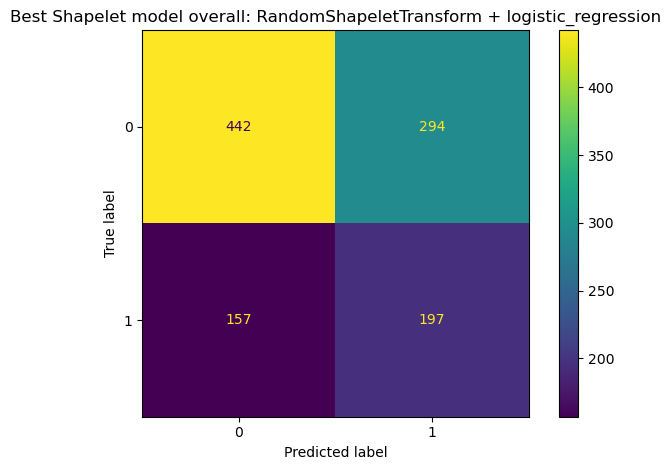

,model,classifier,n_shapelet_samples,max_shapelets,min_shapelet_length,max_shapelet_length,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc,leakage_control
0,Best Shapelet model overall: RandomShapeletTra...,logistic_regression,2000,40,4,24,0.5475,0.019331,0.586239,0.57852,0.569559,0.57852,0.564222,0.59855,0.63288,subject-level train/test split; grouped CV on ...


In [20]:
# ============================================================
# Refit best Shapelet model on full training set
# Evaluate once on the test set
# ============================================================

best_shapelet_transformer = make_shapelet_transformer(
    n_shapelet_samples=int(best_shapelet_config["n_shapelet_samples"]),
    max_shapelets=int(best_shapelet_config["max_shapelets"]),
    min_shapelet_length=int(best_shapelet_config["min_shapelet_length"]),
    max_shapelet_length=int(best_shapelet_config["max_shapelet_length"]),
    random_state=random_state
)

print("Fitting best Shapelet Transformer on full TRAIN only...")

X_train_shapelet_features = best_shapelet_transformer.fit_transform(
    X_train_shapelet_input,
    y_train
)

print("Transforming TEST using train-fitted shapelets...")

X_test_shapelet_features = best_shapelet_transformer.transform(
    X_test_shapelet_input
)

print("Shapelet train feature matrix:", X_train_shapelet_features.shape)
print("Shapelet test feature matrix:", X_test_shapelet_features.shape)

best_shapelet_classifier = make_shapelet_classifier(
    best_shapelet_config["classifier"]
)

print("Fitting best classifier on train shapelet-distance features...")

best_shapelet_classifier.fit(
    X_train_shapelet_features,
    y_train
)

print("Predicting test set...")

y_pred_best_shapelet = best_shapelet_classifier.predict(
    X_test_shapelet_features
)

try:
    y_score_best_shapelet = get_score_for_auc(
        best_shapelet_classifier,
        X_test_shapelet_features
    )
except Exception:
    y_score_best_shapelet = None

final_shapelet_model_name = (
    "Best Shapelet model overall: "
    f"RandomShapeletTransform + {best_shapelet_config['classifier']}"
)

best_shapelet_result = evaluate_classifier(
    model_name=final_shapelet_model_name,
    y_true=y_test,
    y_pred=y_pred_best_shapelet,
    y_score=y_score_best_shapelet,
    show_confusion_matrix=True
)

best_shapelet_result["method_family"] = "shapelets"
best_shapelet_result["n_shapelet_samples"] = int(best_shapelet_config["n_shapelet_samples"])
best_shapelet_result["max_shapelets"] = int(best_shapelet_config["max_shapelets"])
best_shapelet_result["min_shapelet_length"] = int(best_shapelet_config["min_shapelet_length"])
best_shapelet_result["max_shapelet_length"] = int(best_shapelet_config["max_shapelet_length"])
best_shapelet_result["classifier"] = best_shapelet_config["classifier"]
best_shapelet_result["cv_balanced_accuracy_mean"] = best_shapelet_config["cv_balanced_accuracy_mean"]
best_shapelet_result["cv_balanced_accuracy_std"] = best_shapelet_config["cv_balanced_accuracy_std"]
best_shapelet_result["leakage_control"] = (
    "subject-level train/test split; grouped CV on train only; "
    "shapelets fitted only on train; test used only once"
)

best_shapelet_result_df = pd.DataFrame([best_shapelet_result])

display(
    best_shapelet_result_df[
        [
            "model",
            "classifier",
            "n_shapelet_samples",
            "max_shapelets",
            "min_shapelet_length",
            "max_shapelet_length",
            "cv_balanced_accuracy_mean",
            "cv_balanced_accuracy_std",
            "accuracy",
            "balanced_accuracy",
            "precision_macro",
            "recall_macro",
            "f1_macro",
            "f1_weighted",
            "roc_auc",
            "leakage_control"
        ]
    ]
)

In [21]:
# ============================================================
# Analyze retrieved shapelets
# ============================================================

def extract_shapelet_summary(shapelet_transformer, groups_train=None):
    """
    Extract metadata about retrieved shapelets from sktime RandomShapeletTransform.

    Expected shapelet tuple:
    0: information gain
    1: shapelet length
    2: start position
    3: dimension/channel
    4: source instance index in training set
    5: class value
    6: z-normalised shapelet values
    """

    if hasattr(shapelet_transformer, "shapelets"):
        shapelets = shapelet_transformer.shapelets
    elif hasattr(shapelet_transformer, "shapelets_"):
        shapelets = shapelet_transformer.shapelets_
    else:
        raise AttributeError(
            "No shapelets attribute found. Check the fitted RandomShapeletTransform object."
        )

    rows = []

    for rank, shp in enumerate(shapelets):
        info_gain = shp[0]
        length = shp[1]
        start_pos = shp[2]
        dimension = shp[3]
        source_instance_idx = shp[4]
        class_value = shp[5]
        shapelet_values = np.asarray(shp[6])

        row = {
            "rank": rank,
            "information_gain": info_gain,
            "length": length,
            "start_position": start_pos,
            "dimension": dimension,
            "source_instance_index_train": source_instance_idx,
            "class_value": class_value,
            "shapelet_mean": np.mean(shapelet_values),
            "shapelet_std": np.std(shapelet_values),
            "shapelet_min": np.min(shapelet_values),
            "shapelet_max": np.max(shapelet_values)
        }

        if groups_train is not None:
            row["source_subject_id"] = groups_train[int(source_instance_idx)]

        rows.append(row)

    summary_df = pd.DataFrame(rows)
    summary_df = summary_df.sort_values("information_gain", ascending=False).reset_index(drop=True)

    return summary_df


shapelets_summary_df = extract_shapelet_summary(
    shapelet_transformer=best_shapelet_transformer,
    groups_train=groups_train
)

display(shapelets_summary_df.head(20))

print("Number of retrieved shapelets:", len(shapelets_summary_df))

print("\nShapelets by class:")
display(shapelets_summary_df["class_value"].value_counts().sort_index())

print("\nShapelets by channel/dimension:")
display(shapelets_summary_df["dimension"].value_counts().sort_index())

print("\nShapelet length distribution:")
display(shapelets_summary_df["length"].describe())

,rank,information_gain,length,start_position,dimension,source_instance_index_train,class_value,shapelet_mean,shapelet_std,shapelet_min,shapelet_max,source_subject_id
0,0,0.013601,14,2,5,422,0,0.000000e+00,0.0,0.000000,0.000000,675
1,1,0.007758,20,4,3,1736,0,2.220446e-17,1.0,-0.916580,3.023086,1951
2,2,0.007577,13,6,3,1846,0,6.832142e-17,1.0,-1.045429,2.153015,480
3,3,0.007507,10,27,0,763,1,7.494005e-17,1.0,-2.806034,0.965720,1559
4,4,0.007316,13,7,3,1902,0,-5.124106e-17,1.0,-0.983796,2.065124,1294
5,5,0.006842,19,16,3,174,0,0.000000e+00,1.0,-1.309036,2.745309,2751
6,6,0.006800,16,28,3,202,0,1.387779e-17,1.0,-1.300532,2.256181,2489
7,7,0.006744,13,1,3,1103,0,1.537232e-16,1.0,-0.888517,2.028899,3542
8,8,0.006598,16,9,3,406,0,0.000000e+00,1.0,-1.121683,1.886817,558
9,9,0.005997,14,7,3,65,0,9.516197e-17,1.0,-1.395082,1.415815,3829


Number of retrieved shapelets: 40

Shapelets by class:


class_value
0    20
1    20
Name: count, dtype: int64


Shapelets by channel/dimension:


dimension
0     9
3    23
5     8
Name: count, dtype: int64


Shapelet length distribution:


count    40.000000
mean     15.700000
std       4.952078
min       4.000000
25%      13.000000
50%      16.000000
75%      19.250000
max      23.000000
Name: length, dtype: float64

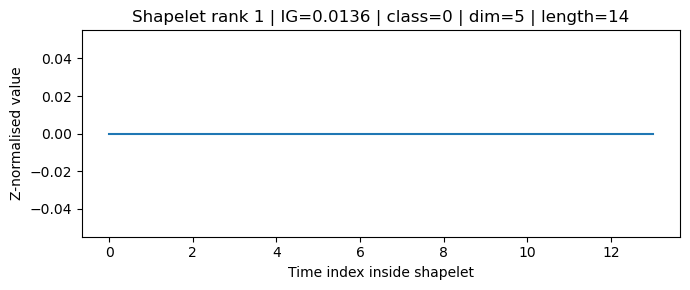

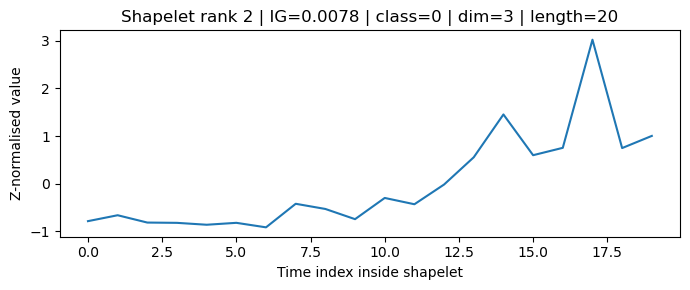

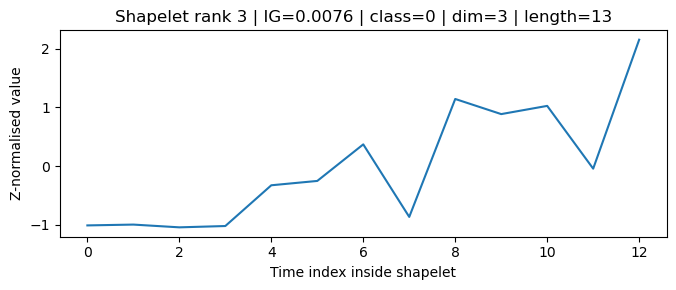

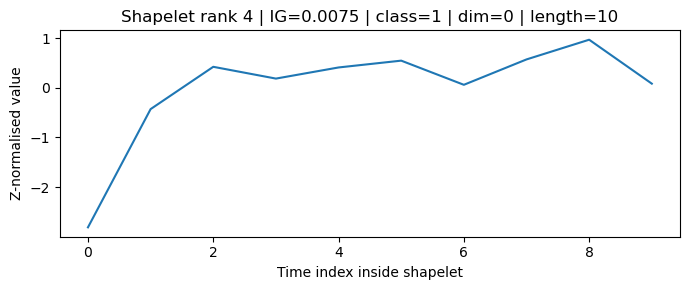

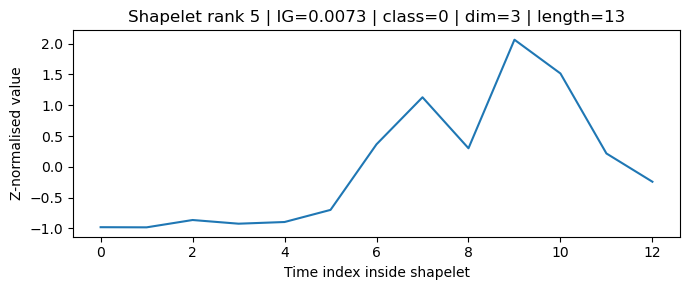

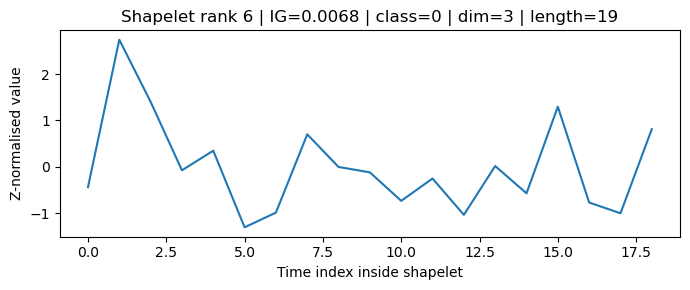

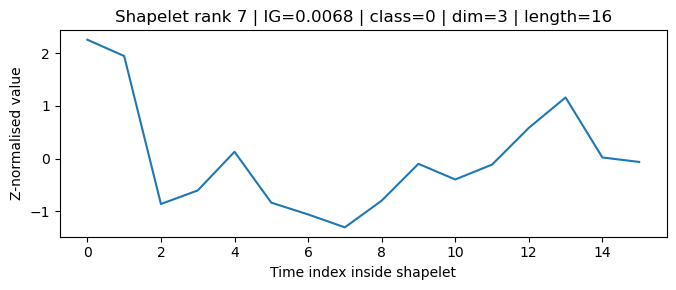

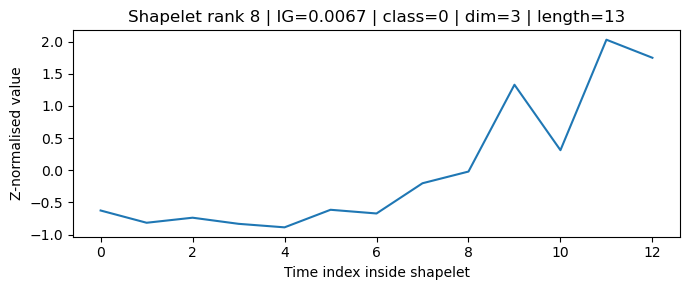

In [22]:
# ============================================================
# Plot top retrieved shapelets
# ============================================================

def get_shapelets_from_transformer(shapelet_transformer):
    if hasattr(shapelet_transformer, "shapelets"):
        return list(shapelet_transformer.shapelets)
    if hasattr(shapelet_transformer, "shapelets_"):
        return list(shapelet_transformer.shapelets_)
    raise AttributeError("No shapelets attribute found.")


def plot_top_shapelets(shapelet_transformer, n_to_plot=8):
    """
    Plot top shapelets by information gain.
    """

    shapelets = get_shapelets_from_transformer(shapelet_transformer)

    shapelets_sorted = sorted(
        shapelets,
        key=lambda x: x[0],
        reverse=True
    )

    n_to_plot = min(n_to_plot, len(shapelets_sorted))

    for i in range(n_to_plot):
        shp = shapelets_sorted[i]

        info_gain = shp[0]
        length = shp[1]
        start_pos = shp[2]
        dimension = shp[3]
        source_instance_idx = shp[4]
        class_value = shp[5]
        shapelet_values = np.asarray(shp[6])

        plt.figure(figsize=(7, 3))
        plt.plot(shapelet_values)
        plt.title(
            f"Shapelet rank {i + 1} | "
            f"IG={info_gain:.4f} | "
            f"class={class_value} | "
            f"dim={dimension} | "
            f"length={length}"
        )
        plt.xlabel("Time index inside shapelet")
        plt.ylabel("Z-normalised value")
        plt.tight_layout()
        plt.show()


plot_top_shapelets(
    shapelet_transformer=best_shapelet_transformer,
    n_to_plot=8
)

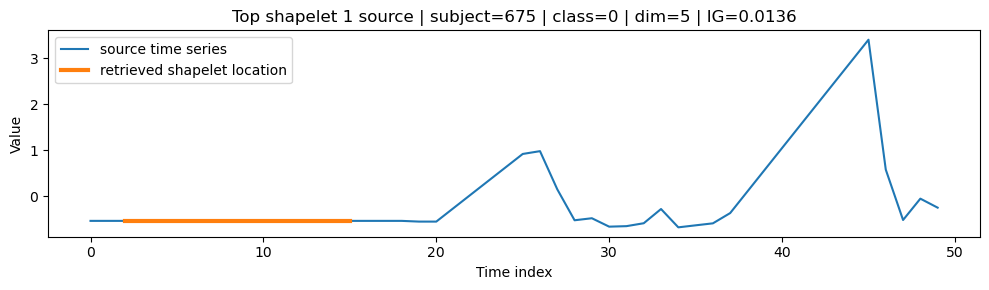

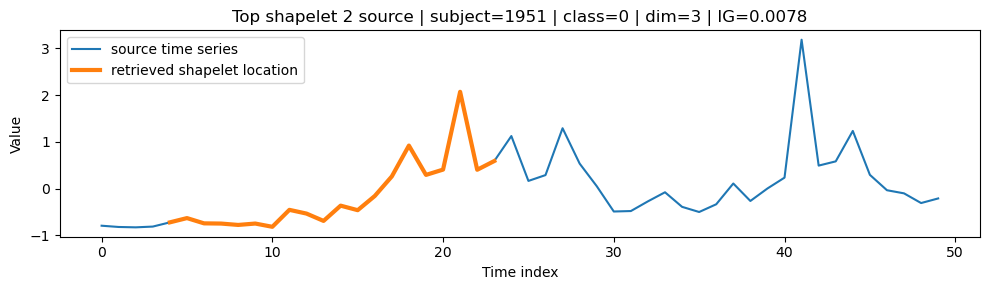

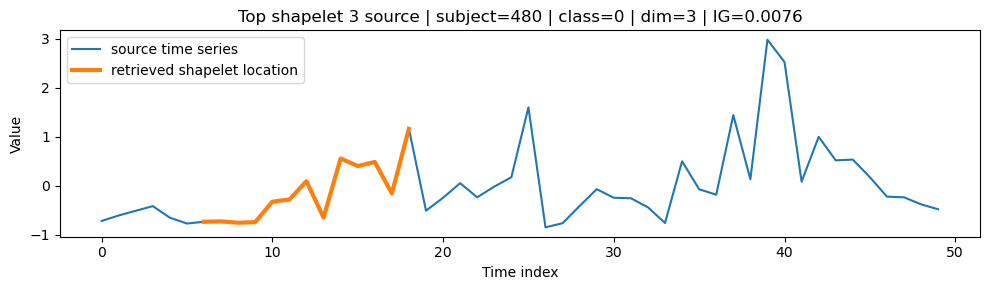

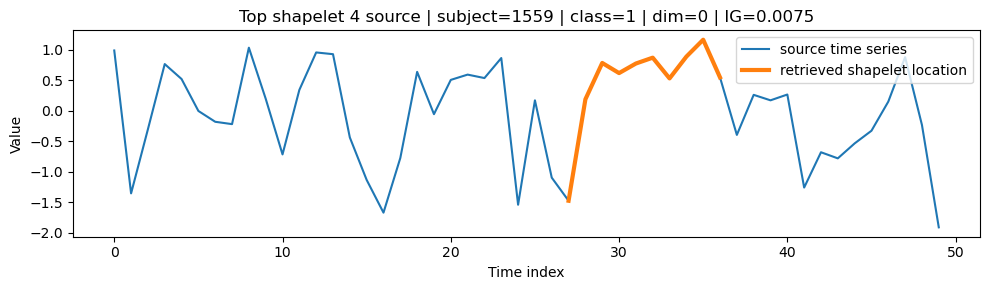

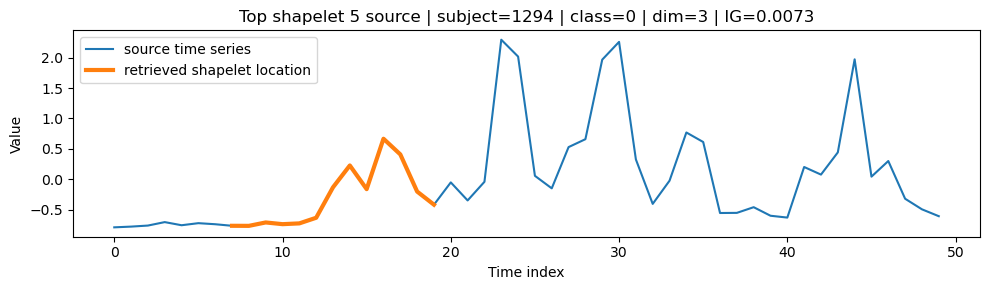

In [23]:
# ============================================================
# Plot source training series and highlight retrieved shapelet
# ============================================================

def plot_shapelet_sources(shapelet_transformer, X_train_ts, groups_train, n_to_plot=5):
    """
    Plot source training time series and highlight where top shapelets came from.

    X_train_ts shape:
        n_instances × n_timepoints × n_channels
    """

    shapelets = get_shapelets_from_transformer(shapelet_transformer)

    shapelets_sorted = sorted(
        shapelets,
        key=lambda x: x[0],
        reverse=True
    )

    n_to_plot = min(n_to_plot, len(shapelets_sorted))

    for i in range(n_to_plot):
        shp = shapelets_sorted[i]

        info_gain = shp[0]
        length = int(shp[1])
        start_pos = int(shp[2])
        dimension = int(shp[3])
        source_instance_idx = int(shp[4])
        class_value = shp[5]

        source_series = X_train_ts[source_instance_idx, :, dimension]
        end_pos = start_pos + length

        plt.figure(figsize=(10, 3))

        plt.plot(
            np.arange(len(source_series)),
            source_series,
            label="source time series"
        )

        plt.plot(
            np.arange(start_pos, end_pos),
            source_series[start_pos:end_pos],
            linewidth=3,
            label="retrieved shapelet location"
        )

        plt.title(
            f"Top shapelet {i + 1} source | "
            f"subject={groups_train[source_instance_idx]} | "
            f"class={class_value} | dim={dimension} | IG={info_gain:.4f}"
        )

        plt.xlabel("Time index")
        plt.ylabel("Value")
        plt.legend()
        plt.tight_layout()
        plt.show()


plot_shapelet_sources(
    shapelet_transformer=best_shapelet_transformer,
    X_train_ts=X_train_ts,
    groups_train=groups_train,
    n_to_plot=5
)

## Minirocket

In [24]:
# ============================================================
# MINIROCKET CLASSIFICATION
# MiniRocketMultivariate + RidgeClassifierCV
# NO DATA LEAKAGE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import StratifiedGroupKFold, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifierCV
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

try:
    from sktime.transformations.panel.rocket import MiniRocketMultivariate
except ImportError:
    raise ImportError(
        "sktime is not installed. Install it with:\n\n"
        "pip install sktime\n"
    )

# ------------------------------------------------------------
# Convert to sktime panel format
# From: n_instances × n_timepoints × n_channels
# To:   n_instances × n_channels × n_timepoints
# ------------------------------------------------------------
X_train_minirocket = np.transpose(X_train_ts, (0, 2, 1)).astype(np.float32)
X_test_minirocket = np.transpose(X_test_ts, (0, 2, 1)).astype(np.float32)

print("MiniRocket train shape:", X_train_minirocket.shape)
print("MiniRocket test shape:", X_test_minirocket.shape)

# ------------------------------------------------------------
# Leakage check
# ------------------------------------------------------------
train_subjects = set(groups_train)
test_subjects = set(groups_test)
overlap_subjects = train_subjects.intersection(test_subjects)

print("\nTrain subjects:", len(train_subjects))
print("Test subjects:", len(test_subjects))
print("Subject overlap:", len(overlap_subjects))

assert len(overlap_subjects) == 0, "DATA LEAKAGE: subject overlap between train and test."

print("\nNo subject-level train/test leakage detected.")

MiniRocket train shape: (3220, 6, 50)
MiniRocket test shape: (1090, 6, 50)

Train subjects: 281
Test subjects: 94
Subject overlap: 0

No subject-level train/test leakage detected.


In [25]:
# ============================================================
# MiniRocket grouped cross-validation
# Model selection uses TRAIN only
# ============================================================

def make_minirocket_transformer(num_kernels, random_state=42):
    """
    Create MiniRocketMultivariate transformer.
    Some sktime versions accept random_state, others do not.
    """
    try:
        return MiniRocketMultivariate(
            num_kernels=num_kernels,
            n_jobs=-1,
            random_state=random_state
        )
    except TypeError:
        return MiniRocketMultivariate(
            num_kernels=num_kernels,
            n_jobs=-1
        )


def make_ridge_classifier():
    """
    Ridge classifier used on MiniRocket features.
    Class imbalance is handled through class_weight='balanced'.
    """
    return RidgeClassifierCV(
        alphas=np.logspace(-3, 3, 10),
        class_weight="balanced"
    )


# ------------------------------------------------------------
# CV splitter: grouped, stratified if available
# ------------------------------------------------------------
N_SPLITS = 5

if HAS_STRATIFIED_GROUP_KFOLD:
    minirocket_cv = StratifiedGroupKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=random_state
    )
else:
    minirocket_cv = GroupKFold(n_splits=N_SPLITS)

# ------------------------------------------------------------
# MiniRocket grid
# ------------------------------------------------------------
minirocket_param_grid = [
    {"num_kernels": 2000},
    {"num_kernels": 5000},
    {"num_kernels": 10000},
]

minirocket_cv_rows = []

start_time = time.time()

for config_id, config in enumerate(minirocket_param_grid, start=1):

    num_kernels = int(config["num_kernels"])

    print("=" * 90)
    print(f"MiniRocket config {config_id}/{len(minirocket_param_grid)}")
    print(f"num_kernels = {num_kernels}")
    print("=" * 90)

    fold_scores = []

    for fold_id, (tr_idx, val_idx) in enumerate(
        minirocket_cv.split(X_train_minirocket, y_train, groups=groups_train),
        start=1
    ):

        X_tr = X_train_minirocket[tr_idx]
        X_val = X_train_minirocket[val_idx]

        y_tr = y_train[tr_idx]
        y_val = y_train[val_idx]

        # ----------------------------------------------------
        # Fit MiniRocket only on the current training fold
        # ----------------------------------------------------
        transformer = make_minirocket_transformer(
            num_kernels=num_kernels,
            random_state=random_state
        )

        X_tr_features = transformer.fit_transform(X_tr, y_tr)
        X_val_features = transformer.transform(X_val)

        # ----------------------------------------------------
        # Scale MiniRocket features using training fold only
        # ----------------------------------------------------
        scaler = StandardScaler(with_mean=False)

        X_tr_features_scaled = scaler.fit_transform(X_tr_features)
        X_val_features_scaled = scaler.transform(X_val_features)

        # ----------------------------------------------------
        # Fit classifier on fold train, evaluate on fold val
        # ----------------------------------------------------
        clf = make_ridge_classifier()
        clf.fit(X_tr_features_scaled, y_tr)

        y_val_pred = clf.predict(X_val_features_scaled)

        fold_bal_acc = balanced_accuracy_score(y_val, y_val_pred)
        fold_acc = accuracy_score(y_val, y_val_pred)

        fold_scores.append(fold_bal_acc)

        print(
            f"Fold {fold_id}: "
            f"balanced_accuracy={fold_bal_acc:.4f}, "
            f"accuracy={fold_acc:.4f}"
        )

    mean_bal_acc = float(np.mean(fold_scores))
    std_bal_acc = float(np.std(fold_scores))

    minirocket_cv_rows.append({
        "config_id": config_id,
        "num_kernels": num_kernels,
        "mean_cv_balanced_accuracy": mean_bal_acc,
        "std_cv_balanced_accuracy": std_bal_acc
    })

    print(
        f"\nConfig {config_id} mean CV balanced accuracy: "
        f"{mean_bal_acc:.4f} ± {std_bal_acc:.4f}"
    )

elapsed_time = time.time() - start_time

minirocket_cv_results_df = pd.DataFrame(minirocket_cv_rows)
minirocket_cv_results_df = minirocket_cv_results_df.sort_values(
    "mean_cv_balanced_accuracy",
    ascending=False
).reset_index(drop=True)

print("\nMiniRocket CV completed.")
print(f"Elapsed time: {elapsed_time:.2f} seconds")

display(minirocket_cv_results_df)

best_minirocket_config = minirocket_cv_results_df.iloc[0].to_dict()

print("\nBest MiniRocket configuration:")
print(best_minirocket_config)

MiniRocket config 1/3
num_kernels = 2000


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Fold 1: balanced_accuracy=0.5424, accuracy=0.5815
Fold 2: balanced_accuracy=0.5269, accuracy=0.5385
Fold 3: balanced_accuracy=0.4925, accuracy=0.4927
Fold 4: balanced_accuracy=0.5045, accuracy=0.5779
Fold 5: balanced_accuracy=0.5406, accuracy=0.5725

Config 1 mean CV balanced accuracy: 0.5214 ± 0.0198
MiniRocket config 2/3
num_kernels = 5000
Fold 1: balanced_accuracy=0.5558, accuracy=0.6066
Fold 2: balanced_accuracy=0.4962, accuracy=0.5275
Fold 3: balanced_accuracy=0.4894, accuracy=0.4898
Fold 4: balanced_accuracy=0.5144, accuracy=0.5812
Fold 5: balanced_accuracy=0.5466, accuracy=0.5835

Config 2 mean CV balanced accuracy: 0.5205 ± 0.0265
MiniRocket config 3/3
num_kernels = 10000
Fold 1: balanced_accuracy=0.5470, accuracy=0.6129
Fold 2: balanced_accuracy=0.5011, accuracy=0.5463
Fold 3: balanced_accuracy=0.4734, accuracy=0.4738
Fold 4: balanced_accuracy=0.5097, accuracy=0.5779
Fold 5: balanced_accuracy=0.5312, accuracy=0.5741

Config 3 mean CV balanced accuracy: 0.5125 ± 0.0253

MiniRoc

,config_id,num_kernels,mean_cv_balanced_accuracy,std_cv_balanced_accuracy
0,1,2000,0.521396,0.019816
1,2,5000,0.520477,0.026541
2,3,10000,0.512477,0.025325



Best MiniRocket configuration:
{'config_id': 1.0, 'num_kernels': 2000.0, 'mean_cv_balanced_accuracy': 0.5213955729245121, 'std_cv_balanced_accuracy': 0.019816235325250568}


Refitting best MiniRocket model on full training set
Best num_kernels = 2000
MiniRocket train feature matrix: (3220, 1932)
MiniRocket test feature matrix: (1090, 1932)
Best MiniRocket overall: MiniRocketMultivariate num_kernels=2000 + RidgeClassifierCV
              precision    recall  f1-score   support

           0       0.69      0.64      0.67       736
           1       0.36      0.41      0.38       354

    accuracy                           0.57      1090
   macro avg       0.53      0.53      0.53      1090
weighted avg       0.58      0.57      0.58      1090


MiniRocketMultivariate num_kernels=2000 + RidgeClassifierCV
              precision    recall  f1-score   support

           0       0.69      0.64      0.67       736
           1       0.36      0.41      0.38       354

    accuracy                           0.57      1090
   macro avg       0.53      0.53      0.53      1090
weighted avg       0.58      0.57      0.58      1090

Accuracy: 0.5678899082568807
Bal

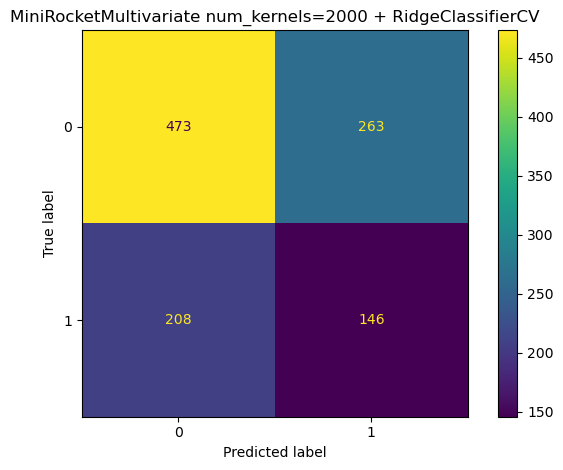

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc
0,MiniRocketMultivariate num_kernels=2000 + Ridg...,0.56789,0.527546,0.525768,0.527546,0.525154,0.584925,0.56789,0.575078,0.552717


In [26]:
# ============================================================
# Refit best MiniRocket model on full TRAIN
# Evaluate once on TEST
# ============================================================

best_num_kernels = int(best_minirocket_config["num_kernels"])

print("=" * 90)
print("Refitting best MiniRocket model on full training set")
print(f"Best num_kernels = {best_num_kernels}")
print("=" * 90)

# ------------------------------------------------------------
# Fit transformer on full training set only
# ------------------------------------------------------------
best_minirocket_transformer = make_minirocket_transformer(
    num_kernels=best_num_kernels,
    random_state=random_state
)

X_train_minirocket_features = best_minirocket_transformer.fit_transform(
    X_train_minirocket,
    y_train
)

X_test_minirocket_features = best_minirocket_transformer.transform(
    X_test_minirocket
)

print("MiniRocket train feature matrix:", X_train_minirocket_features.shape)
print("MiniRocket test feature matrix:", X_test_minirocket_features.shape)

# ------------------------------------------------------------
# Scale features using train only
# ------------------------------------------------------------
best_minirocket_scaler = StandardScaler(with_mean=False)

X_train_minirocket_scaled = best_minirocket_scaler.fit_transform(
    X_train_minirocket_features
)

X_test_minirocket_scaled = best_minirocket_scaler.transform(
    X_test_minirocket_features
)

# ------------------------------------------------------------
# Fit final classifier
# ------------------------------------------------------------
best_minirocket_classifier = make_ridge_classifier()

best_minirocket_classifier.fit(
    X_train_minirocket_scaled,
    y_train
)

# ------------------------------------------------------------
# Test prediction
# ------------------------------------------------------------
y_pred_best_minirocket = best_minirocket_classifier.predict(
    X_test_minirocket_scaled
)

try:
    y_score_best_minirocket = best_minirocket_classifier.decision_function(
        X_test_minirocket_scaled
    )
except Exception:
    y_score_best_minirocket = None

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------
print("=" * 90)
print(
    f"Best MiniRocket overall: "
    f"MiniRocketMultivariate num_kernels={best_num_kernels} + RidgeClassifierCV"
)
print("=" * 90)

print(classification_report(y_test, y_pred_best_minirocket))

minirocket_test_results = evaluate_classifier(
    model_name=(
        f"MiniRocketMultivariate num_kernels={best_num_kernels} "
        "+ RidgeClassifierCV"
    ),
    y_true=y_test,
    y_pred=y_pred_best_minirocket,
    y_score=y_score_best_minirocket,
    show_confusion_matrix=True
)

display(pd.DataFrame([minirocket_test_results]))

In [27]:
# ============================================================
# MiniRocket diagnostic: scaling variants + threshold tuning
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import RidgeClassifierCV
from sklearn.model_selection import StratifiedGroupKFold, GroupKFold
import numpy as np
import pandas as pd
import time

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def make_minirocket_transformer(num_kernels, random_state=42):
    try:
        return MiniRocketMultivariate(
            num_kernels=num_kernels,
            n_jobs=-1,
            random_state=random_state
        )
    except TypeError:
        return MiniRocketMultivariate(
            num_kernels=num_kernels,
            n_jobs=-1
        )


def make_ridge_classifier():
    return RidgeClassifierCV(
        alphas=np.logspace(-3, 3, 10),
        class_weight="balanced"
    )


def get_scaler(scaler_type):
    if scaler_type == "none":
        return None
    elif scaler_type == "standard":
        return StandardScaler()
    elif scaler_type == "standard_no_mean":
        return StandardScaler(with_mean=False)
    else:
        raise ValueError(f"Unknown scaler_type: {scaler_type}")


def find_best_threshold(y_true, scores):
    """
    Select threshold maximizing balanced accuracy.
    This is done only on CV out-of-fold scores.
    """
    thresholds = np.quantile(scores, np.linspace(0.01, 0.99, 99))
    
    best_thr = 0.0
    best_bal_acc = -np.inf
    
    for thr in thresholds:
        preds = (scores >= thr).astype(int)
        bal_acc = balanced_accuracy_score(y_true, preds)
        
        if bal_acc > best_bal_acc:
            best_bal_acc = bal_acc
            best_thr = thr
    
    return best_thr, best_bal_acc


# ------------------------------------------------------------
# Configurations to test
# ------------------------------------------------------------
diagnostic_grid = [
    {"num_kernels": 10000, "scaler_type": "none"},
    {"num_kernels": 10000, "scaler_type": "standard"},
    {"num_kernels": 10000, "scaler_type": "standard_no_mean"},
    {"num_kernels": 20000, "scaler_type": "none"},
    {"num_kernels": 20000, "scaler_type": "standard"},
]

N_SPLITS = 5

if HAS_STRATIFIED_GROUP_KFOLD:
    cv = StratifiedGroupKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=random_state
    )
else:
    cv = GroupKFold(n_splits=N_SPLITS)

diagnostic_rows = []

# ------------------------------------------------------------
# Cross-validation with out-of-fold scores
# ------------------------------------------------------------
for config_id, config in enumerate(diagnostic_grid, start=1):
    
    num_kernels = config["num_kernels"]
    scaler_type = config["scaler_type"]
    
    print("=" * 90)
    print(f"MiniRocket diagnostic config {config_id}/{len(diagnostic_grid)}")
    print(f"num_kernels={num_kernels}, scaler={scaler_type}")
    print("=" * 90)
    
    oof_scores = np.zeros(len(y_train), dtype=float)
    oof_preds_default = np.zeros(len(y_train), dtype=int)
    
    fold_bal_accs_default = []
    
    start_time = time.time()
    
    for fold_id, (tr_idx, val_idx) in enumerate(
        cv.split(X_train_minirocket, y_train, groups=groups_train),
        start=1
    ):
        X_tr = X_train_minirocket[tr_idx]
        X_val = X_train_minirocket[val_idx]
        y_tr = y_train[tr_idx]
        y_val = y_train[val_idx]
        
        transformer = make_minirocket_transformer(
            num_kernels=num_kernels,
            random_state=random_state
        )
        
        X_tr_feat = transformer.fit_transform(X_tr, y_tr)
        X_val_feat = transformer.transform(X_val)
        
        scaler = get_scaler(scaler_type)
        
        if scaler is not None:
            X_tr_feat = scaler.fit_transform(X_tr_feat)
            X_val_feat = scaler.transform(X_val_feat)
        
        clf = make_ridge_classifier()
        clf.fit(X_tr_feat, y_tr)
        
        val_scores = clf.decision_function(X_val_feat)
        val_preds_default = clf.predict(X_val_feat)
        
        oof_scores[val_idx] = val_scores
        oof_preds_default[val_idx] = val_preds_default
        
        fold_bal_acc = balanced_accuracy_score(y_val, val_preds_default)
        fold_bal_accs_default.append(fold_bal_acc)
        
        print(f"Fold {fold_id}: default threshold bal_acc={fold_bal_acc:.4f}")
    
    # Default threshold performance
    cv_bal_acc_default = balanced_accuracy_score(y_train, oof_preds_default)
    
    # Tuned threshold performance, using only OOF training scores
    best_thr, cv_bal_acc_tuned = find_best_threshold(y_train, oof_scores)
    
    elapsed = time.time() - start_time
    
    diagnostic_rows.append({
        "config_id": config_id,
        "num_kernels": num_kernels,
        "scaler_type": scaler_type,
        "cv_bal_acc_default_threshold": cv_bal_acc_default,
        "cv_bal_acc_tuned_threshold": cv_bal_acc_tuned,
        "best_threshold": best_thr,
        "mean_fold_bal_acc_default": np.mean(fold_bal_accs_default),
        "std_fold_bal_acc_default": np.std(fold_bal_accs_default),
        "elapsed_seconds": elapsed
    })
    
    print(f"\nOOF balanced accuracy, default threshold: {cv_bal_acc_default:.4f}")
    print(f"OOF balanced accuracy, tuned threshold:   {cv_bal_acc_tuned:.4f}")
    print(f"Best threshold: {best_thr:.4f}")
    print(f"Elapsed: {elapsed:.2f}s")

minirocket_diagnostic_df = pd.DataFrame(diagnostic_rows)
minirocket_diagnostic_df = minirocket_diagnostic_df.sort_values(
    "cv_bal_acc_tuned_threshold",
    ascending=False
).reset_index(drop=True)

display(minirocket_diagnostic_df)

best_minirocket_diagnostic_config = minirocket_diagnostic_df.iloc[0].to_dict()

print("\nBest diagnostic MiniRocket config:")
print(best_minirocket_diagnostic_config)

MiniRocket diagnostic config 1/5
num_kernels=10000, scaler=none
Fold 1: default threshold bal_acc=0.5606
Fold 2: default threshold bal_acc=0.5522
Fold 3: default threshold bal_acc=0.5026
Fold 4: default threshold bal_acc=0.5394
Fold 5: default threshold bal_acc=0.5699

OOF balanced accuracy, default threshold: 0.5393
OOF balanced accuracy, tuned threshold:   0.5510
Best threshold: -0.1344
Elapsed: 15.34s
MiniRocket diagnostic config 2/5
num_kernels=10000, scaler=standard
Fold 1: default threshold bal_acc=0.5470
Fold 2: default threshold bal_acc=0.5011
Fold 3: default threshold bal_acc=0.4734
Fold 4: default threshold bal_acc=0.5097
Fold 5: default threshold bal_acc=0.5312

OOF balanced accuracy, default threshold: 0.5074
OOF balanced accuracy, tuned threshold:   0.5231
Best threshold: -0.2400
Elapsed: 16.07s
MiniRocket diagnostic config 3/5
num_kernels=10000, scaler=standard_no_mean
Fold 1: default threshold bal_acc=0.5470
Fold 2: default threshold bal_acc=0.5011
Fold 3: default thresh

,config_id,num_kernels,scaler_type,cv_bal_acc_default_threshold,cv_bal_acc_tuned_threshold,best_threshold,mean_fold_bal_acc_default,std_fold_bal_acc_default,elapsed_seconds
0,1,10000,none,0.539345,0.551006,-0.134424,0.544950,0.023423,15.340656
1,4,20000,none,0.534736,0.543992,-0.135905,0.540514,0.034297,18.194918
2,2,10000,standard,0.507395,0.523117,-0.239955,0.512477,0.025325,16.073326
3,3,10000,standard_no_mean,0.507395,0.523117,-0.239955,0.512477,0.025325,15.623415
4,5,20000,standard,0.509905,0.520025,-0.455438,0.515142,0.032431,21.587304



Best diagnostic MiniRocket config:
{'config_id': 1, 'num_kernels': 10000, 'scaler_type': 'none', 'cv_bal_acc_default_threshold': 0.539344986981886, 'cv_bal_acc_tuned_threshold': 0.5510064672876377, 'best_threshold': -0.13442420255489254, 'mean_fold_bal_acc_default': 0.544949709967214, 'std_fold_bal_acc_default': 0.023423179780908455, 'elapsed_seconds': 15.34065580368042}


Refitting best MiniRocket diagnostic configuration
num_kernels=10000
scaler=none
threshold=-0.1344

MiniRocket test performance with default threshold:
Accuracy: 0.5752
Balanced accuracy: 0.5601
              precision    recall  f1-score   support

           0       0.72      0.60      0.66       736
           1       0.39      0.52      0.44       354

    accuracy                           0.58      1090
   macro avg       0.55      0.56      0.55      1090
weighted avg       0.61      0.58      0.59      1090


MiniRocket test performance with CV-tuned threshold:
Accuracy: 0.4789
Balanced accuracy: 0.5599
              precision    recall  f1-score   support

           0       0.77      0.33      0.46       736
           1       0.36      0.79      0.50       354

    accuracy                           0.48      1090
   macro avg       0.56      0.56      0.48      1090
weighted avg       0.63      0.48      0.47      1090



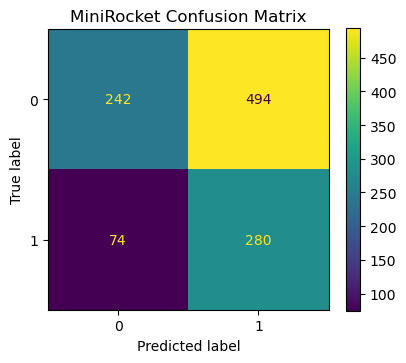

In [28]:
# ============================================================
# Refit best diagnostic MiniRocket model and evaluate on test
# ============================================================

best_num_kernels = int(best_minirocket_diagnostic_config["num_kernels"])
best_scaler_type = best_minirocket_diagnostic_config["scaler_type"]
best_threshold = float(best_minirocket_diagnostic_config["best_threshold"])

print("=" * 90)
print("Refitting best MiniRocket diagnostic configuration")
print(f"num_kernels={best_num_kernels}")
print(f"scaler={best_scaler_type}")
print(f"threshold={best_threshold:.4f}")
print("=" * 90)

# ------------------------------------------------------------
# Fit MiniRocket on full training set only
# ------------------------------------------------------------
final_minirocket_transformer = make_minirocket_transformer(
    num_kernels=best_num_kernels,
    random_state=random_state
)

X_train_feat = final_minirocket_transformer.fit_transform(
    X_train_minirocket,
    y_train
)

X_test_feat = final_minirocket_transformer.transform(
    X_test_minirocket
)

# ------------------------------------------------------------
# Scaling
# ------------------------------------------------------------
final_scaler = get_scaler(best_scaler_type)

if final_scaler is not None:
    X_train_feat = final_scaler.fit_transform(X_train_feat)
    X_test_feat = final_scaler.transform(X_test_feat)

# ------------------------------------------------------------
# Classifier
# ------------------------------------------------------------
final_minirocket_clf = make_ridge_classifier()
final_minirocket_clf.fit(X_train_feat, y_train)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------
test_scores = final_minirocket_clf.decision_function(X_test_feat)

y_pred_default = final_minirocket_clf.predict(X_test_feat)
y_pred_tuned = (test_scores >= best_threshold).astype(int)

print("\nMiniRocket test performance with default threshold:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_default):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_default):.4f}")
print(classification_report(y_test, y_pred_default))

print("\nMiniRocket test performance with CV-tuned threshold:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_tuned):.4f}")
print(classification_report(y_test, y_pred_tuned))

# Save final prediction as the tuned-threshold version
y_pred_best_minirocket = y_pred_tuned
y_score_best_minirocket = test_scores

cm_minirocket = confusion_matrix(y_test, y_pred_best_minirocket)

fig, ax = plt.subplots(figsize=(4.2, 3.6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_minirocket,
    display_labels=np.unique(y_test)
)
disp.plot(
    ax=ax,
    cmap="viridis",
    colorbar=True,
    values_format="d"
)
ax.set_title("MiniRocket Confusion Matrix")
plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# Prepare FULL subject-scaled time series for MiniRocket
# Do NOT use PAA for MiniRocket
# ============================================================

# Retrieve full-resolution subject-scaled windows
CMI_timeseries_subject_scaled = preprocessed_outputs["CMI_timeseries_subject_scaled"]

signal_cols = preprocessed_outputs["signal_cols"]
id_col = preprocessed_outputs["id_col"]
target_col = preprocessed_outputs["target_col"]

# Build full-resolution 3D array:
# n_instances x n_timepoints x n_channels
X_full_list = []

for ts_df in CMI_timeseries_subject_scaled:
    X_full_list.append(
        ts_df[signal_cols].to_numpy(dtype=float)
    )

X_ts_full_subject = np.stack(X_full_list, axis=0)

print("Full-resolution subject-scaled X shape:", X_ts_full_subject.shape)
print("Original PAA X shape:", X_ts.shape)

assert X_ts_full_subject.shape[0] == len(y) == len(groups)

# Use the SAME subject-level split already created before
X_train_full_raw = X_ts_full_subject[train_idx]
X_test_full_raw = X_ts_full_subject[test_idx]

# Train-only imputation, same function already defined in the notebook
X_train_full, X_test_full, full_train_channel_medians = impute_non_finite_3d_train_only(
    X_train_full_raw,
    X_test_full_raw
)

assert np.isfinite(X_train_full).all()
assert np.isfinite(X_test_full).all()

# Convert to sktime format:
# from n_instances x n_timepoints x n_channels
# to   n_instances x n_channels x n_timepoints
X_train_minirocket = np.transpose(X_train_full, (0, 2, 1)).astype(np.float32)
X_test_minirocket = np.transpose(X_test_full, (0, 2, 1)).astype(np.float32)

print("MiniRocket train shape:", X_train_minirocket.shape)
print("MiniRocket test shape:", X_test_minirocket.shape)

# Leakage check
assert len(set(groups_train).intersection(set(groups_test))) == 0
print("No subject-level leakage detected.")

Full-resolution subject-scaled X shape: (4310, 200, 6)
Original PAA X shape: (4310, 50, 6)
MiniRocket train shape: (3220, 6, 200)
MiniRocket test shape: (1090, 6, 200)
No subject-level leakage detected.


In [32]:
# ============================================================
# MiniRocket CV on full-resolution subject-scaled time series
# Grid includes class_weight = None vs "balanced"
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, accuracy_score

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def make_minirocket_transformer(num_kernels, random_state=42):
    try:
        return MiniRocketMultivariate(
            num_kernels=num_kernels,
            n_jobs=-1,
            random_state=random_state
        )
    except TypeError:
        return MiniRocketMultivariate(
            num_kernels=num_kernels,
            n_jobs=-1
        )


def make_minirocket_classifier(class_weight=None):
    return RidgeClassifierCV(
        alphas=np.logspace(-3, 3, 10),
        class_weight=class_weight
    )


def get_scaler(scaler_type):
    if scaler_type == "none":
        return None
    elif scaler_type == "standard":
        return StandardScaler()
    else:
        raise ValueError(f"Unknown scaler_type: {scaler_type}")


def find_best_threshold_for_balanced_accuracy(y_true, scores):
    thresholds = np.unique(
        np.concatenate([
            np.array([0.0]),
            np.quantile(scores, np.linspace(0.01, 0.99, 99))
        ])
    )

    best_threshold = 0.0
    best_bal_acc = -np.inf

    for threshold in thresholds:
        y_pred = (scores >= threshold).astype(int)
        bal_acc = balanced_accuracy_score(y_true, y_pred)

        if bal_acc > best_bal_acc:
            best_bal_acc = bal_acc
            best_threshold = threshold

    return float(best_threshold), float(best_bal_acc)


# ------------------------------------------------------------
# CV splitter
# ------------------------------------------------------------
N_SPLITS = 5

try:
    random_state
except NameError:
    random_state = 42

cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=random_state
)

# ------------------------------------------------------------
# MiniRocket grid
# ------------------------------------------------------------
minirocket_grid = [
    {"num_kernels": 10000, "scaler_type": "none",     "class_weight": None},
    {"num_kernels": 10000, "scaler_type": "none",     "class_weight": "balanced"},
    {"num_kernels": 10000, "scaler_type": "standard", "class_weight": None},
    {"num_kernels": 10000, "scaler_type": "standard", "class_weight": "balanced"},

    {"num_kernels": 20000, "scaler_type": "none",     "class_weight": None},
    {"num_kernels": 20000, "scaler_type": "none",     "class_weight": "balanced"},
    {"num_kernels": 20000, "scaler_type": "standard", "class_weight": None},
    {"num_kernels": 20000, "scaler_type": "standard", "class_weight": "balanced"},
]

minirocket_cv_rows = []

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------
for config_id, config in enumerate(minirocket_grid, start=1):

    num_kernels = int(config["num_kernels"])
    scaler_type = config["scaler_type"]
    class_weight = config["class_weight"]

    print("=" * 90)
    print(f"MiniRocket configuration {config_id}/{len(minirocket_grid)}")
    print(f"num_kernels={num_kernels}, scaler={scaler_type}, class_weight={class_weight}")
    print("=" * 90)

    oof_scores = np.zeros(len(y_train), dtype=float)
    oof_preds_default = np.zeros(len(y_train), dtype=int)

    fold_bal_accs = []
    fold_accs = []

    start_time = time.time()

    for fold_id, (tr_idx, val_idx) in enumerate(
        cv.split(X_train_minirocket, y_train, groups=groups_train),
        start=1
    ):

        X_tr = X_train_minirocket[tr_idx]
        X_val = X_train_minirocket[val_idx]

        y_tr = y_train[tr_idx]
        y_val = y_train[val_idx]

        # Fit MiniRocket only on the training fold
        transformer = make_minirocket_transformer(
            num_kernels=num_kernels,
            random_state=random_state
        )

        X_tr_feat = transformer.fit_transform(X_tr, y_tr)
        X_val_feat = transformer.transform(X_val)

        # Optional scaling fitted only on the training fold
        scaler = get_scaler(scaler_type)

        if scaler is not None:
            X_tr_feat = scaler.fit_transform(X_tr_feat)
            X_val_feat = scaler.transform(X_val_feat)

        # Classifier
        clf = make_minirocket_classifier(class_weight=class_weight)
        clf.fit(X_tr_feat, y_tr)

        y_val_pred = clf.predict(X_val_feat)
        y_val_score = clf.decision_function(X_val_feat)

        oof_preds_default[val_idx] = y_val_pred
        oof_scores[val_idx] = y_val_score

        fold_bal_acc = balanced_accuracy_score(y_val, y_val_pred)
        fold_acc = accuracy_score(y_val, y_val_pred)

        fold_bal_accs.append(fold_bal_acc)
        fold_accs.append(fold_acc)

        print(
            f"Fold {fold_id}: "
            f"balanced_accuracy={fold_bal_acc:.4f}, "
            f"accuracy={fold_acc:.4f}"
        )

    # OOF evaluation with default threshold
    oof_bal_acc_default = balanced_accuracy_score(y_train, oof_preds_default)
    oof_acc_default = accuracy_score(y_train, oof_preds_default)

    # OOF threshold tuning, diagnostic only unless explicitly selected later
    best_threshold, oof_bal_acc_tuned = find_best_threshold_for_balanced_accuracy(
        y_true=y_train,
        scores=oof_scores
    )

    oof_preds_tuned = (oof_scores >= best_threshold).astype(int)
    oof_acc_tuned = accuracy_score(y_train, oof_preds_tuned)

    elapsed_time = time.time() - start_time

    minirocket_cv_rows.append({
        "config_id": config_id,
        "num_kernels": num_kernels,
        "scaler_type": scaler_type,
        "class_weight": class_weight if class_weight is not None else "none",

        "mean_fold_balanced_accuracy": float(np.mean(fold_bal_accs)),
        "std_fold_balanced_accuracy": float(np.std(fold_bal_accs)),

        "oof_balanced_accuracy_default": float(oof_bal_acc_default),
        "oof_accuracy_default": float(oof_acc_default),

        "oof_balanced_accuracy_tuned": float(oof_bal_acc_tuned),
        "oof_accuracy_tuned": float(oof_acc_tuned),
        "best_threshold": float(best_threshold),

        "elapsed_seconds": float(elapsed_time)
    })

    print("\nOOF results:")
    print(f"Default threshold balanced accuracy: {oof_bal_acc_default:.4f}")
    print(f"Tuned threshold balanced accuracy:   {oof_bal_acc_tuned:.4f}")
    print(f"Best threshold: {best_threshold:.4f}")
    print(f"Elapsed time: {elapsed_time:.2f} seconds")

# ------------------------------------------------------------
# Select best configuration
# ------------------------------------------------------------
minirocket_cv_results_df = pd.DataFrame(minirocket_cv_rows)

# I recommend selecting by default-threshold OOF balanced accuracy,
# because this is the canonical MiniRocket + RidgeClassifierCV setup.
MINIROCKET_SELECTION_METRIC = "oof_balanced_accuracy_default"

minirocket_cv_results_df = minirocket_cv_results_df.sort_values(
    MINIROCKET_SELECTION_METRIC,
    ascending=False
).reset_index(drop=True)

print("\nMiniRocket CV results:")
display(minirocket_cv_results_df)

best_minirocket_config = minirocket_cv_results_df.iloc[0].to_dict()

print("\nBest MiniRocket configuration:")
print(best_minirocket_config)

MiniRocket configuration 1/8
num_kernels=10000, scaler=none, class_weight=None
Fold 1: balanced_accuracy=0.5541, accuracy=0.6975
Fold 2: balanced_accuracy=0.5434, accuracy=0.6421
Fold 3: balanced_accuracy=0.4960, accuracy=0.4971
Fold 4: balanced_accuracy=0.4957, accuracy=0.6818
Fold 5: balanced_accuracy=0.5359, accuracy=0.6381

OOF results:
Default threshold balanced accuracy: 0.5179
Tuned threshold balanced accuracy:   0.5411
Best threshold: -0.2887
Elapsed time: 20.53 seconds
MiniRocket configuration 2/8
num_kernels=10000, scaler=none, class_weight=balanced
Fold 1: balanced_accuracy=0.5972, accuracy=0.6207
Fold 2: balanced_accuracy=0.5544, accuracy=0.5495
Fold 3: balanced_accuracy=0.4983, accuracy=0.4985
Fold 4: balanced_accuracy=0.5207, accuracy=0.5828
Fold 5: balanced_accuracy=0.5926, accuracy=0.6349

OOF results:
Default threshold balanced accuracy: 0.5465
Tuned threshold balanced accuracy:   0.5491
Best threshold: 0.0158
Elapsed time: 19.60 seconds
MiniRocket configuration 3/8
nu

,config_id,num_kernels,scaler_type,class_weight,mean_fold_balanced_accuracy,std_fold_balanced_accuracy,oof_balanced_accuracy_default,oof_accuracy_default,oof_balanced_accuracy_tuned,oof_accuracy_tuned,best_threshold,elapsed_seconds
0,6,20000,none,balanced,0.553041,0.040557,0.547987,0.573913,0.553958,0.588199,0.022512,23.974257
1,2,10000,none,balanced,0.552640,0.038920,0.546548,0.576087,0.549055,0.583851,0.015824,19.601346
2,5,20000,none,none,0.525763,0.024776,0.520081,0.644099,0.543422,0.518323,-0.390025,25.090137
3,1,10000,none,none,0.525029,0.024488,0.517893,0.628882,0.541069,0.559938,-0.288685,20.528637
4,4,10000,standard,balanced,0.523836,0.029195,0.516890,0.571118,0.529262,0.519255,-0.298560,21.026539
5,3,10000,standard,none,0.521316,0.031800,0.514090,0.589441,0.526619,0.523602,-0.355221,20.536326
6,8,20000,standard,balanced,0.511495,0.032774,0.506566,0.566460,0.527750,0.527950,-0.275463,28.769891
7,7,20000,standard,none,0.510847,0.031434,0.504797,0.577019,0.525218,0.522360,-0.343242,24.813141



Best MiniRocket configuration:
{'config_id': 6, 'num_kernels': 20000, 'scaler_type': 'none', 'class_weight': 'balanced', 'mean_fold_balanced_accuracy': 0.553040859136412, 'std_fold_balanced_accuracy': 0.04055689157290944, 'oof_balanced_accuracy_default': 0.5479868913857677, 'oof_accuracy_default': 0.5739130434782609, 'oof_balanced_accuracy_tuned': 0.5539581679963242, 'oof_accuracy_tuned': 0.5881987577639751, 'best_threshold': 0.022511752895402172, 'elapsed_seconds': 23.974256992340088}


Refitting best MiniRocket model on full training set
num_kernels = 20000
scaler_type = none
CV-tuned threshold = 0.0225
MiniRocket feature matrix - train: (3220, 19992)
MiniRocket feature matrix - test: (1090, 19992)

MiniRocket test performance - default threshold
Accuracy: 0.6780
Balanced accuracy: 0.5365
              precision    recall  f1-score   support

           0       0.69      0.94      0.80       736
           1       0.52      0.13      0.21       354

    accuracy                           0.68      1090
   macro avg       0.60      0.54      0.50      1090
weighted avg       0.64      0.68      0.61      1090


MiniRocket test performance - CV-tuned threshold
Accuracy: 0.6817
Balanced accuracy: 0.5385
              precision    recall  f1-score   support

           0       0.69      0.95      0.80       736
           1       0.54      0.13      0.21       354

    accuracy                           0.68      1090
   macro avg       0.62      0.54      0.51      1090

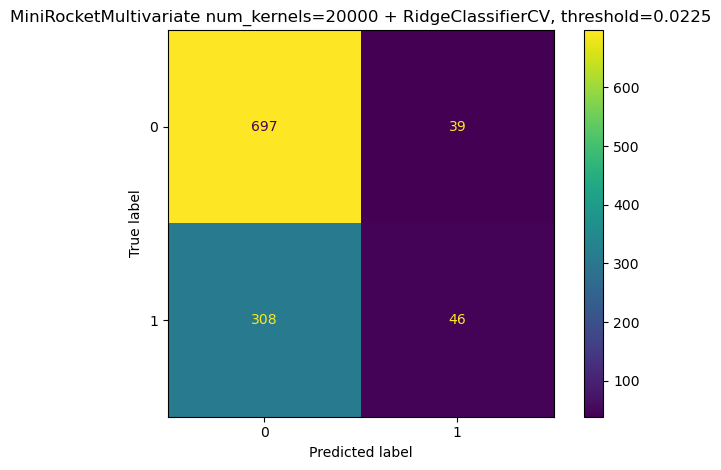

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc
0,MiniRocketMultivariate num_kernels=20000 + Rid...,0.681651,0.538477,0.617354,0.538477,0.505128,0.644052,0.681651,0.60871,0.637915


In [33]:
# ============================================================
# Refit best MiniRocket on full training set and evaluate on test
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score
)
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Retrieve best configuration
# ------------------------------------------------------------
best_num_kernels = int(best_minirocket_config["num_kernels"])
best_scaler_type = best_minirocket_config["scaler_type"]
best_threshold = float(best_minirocket_config["best_threshold"])

print("=" * 90)
print("Refitting best MiniRocket model on full training set")
print(f"num_kernels = {best_num_kernels}")
print(f"scaler_type = {best_scaler_type}")
print(f"CV-tuned threshold = {best_threshold:.4f}")
print("=" * 90)

# ------------------------------------------------------------
# Fit MiniRocket only on full training set
# ------------------------------------------------------------
final_minirocket_transformer = make_minirocket_transformer(
    num_kernels=best_num_kernels,
    random_state=random_state
)

X_train_minirocket_feat = final_minirocket_transformer.fit_transform(
    X_train_minirocket,
    y_train
)

X_test_minirocket_feat = final_minirocket_transformer.transform(
    X_test_minirocket
)

print("MiniRocket feature matrix - train:", X_train_minirocket_feat.shape)
print("MiniRocket feature matrix - test:", X_test_minirocket_feat.shape)

# ------------------------------------------------------------
# Optional scaling, fitted on train only
# ------------------------------------------------------------
final_minirocket_scaler = get_scaler(best_scaler_type)

if final_minirocket_scaler is not None:
    X_train_minirocket_feat = final_minirocket_scaler.fit_transform(
        X_train_minirocket_feat
    )
    X_test_minirocket_feat = final_minirocket_scaler.transform(
        X_test_minirocket_feat
    )

# ------------------------------------------------------------
# Fit final classifier
# ------------------------------------------------------------
final_minirocket_classifier = make_minirocket_classifier()

final_minirocket_classifier.fit(
    X_train_minirocket_feat,
    y_train
)

# ------------------------------------------------------------
# Predict on test set
# ------------------------------------------------------------
y_test_score_minirocket = final_minirocket_classifier.decision_function(
    X_test_minirocket_feat
)

y_test_pred_minirocket_default = final_minirocket_classifier.predict(
    X_test_minirocket_feat
)

y_test_pred_minirocket_tuned = (
    y_test_score_minirocket >= best_threshold
).astype(int)

# ------------------------------------------------------------
# Evaluate default threshold
# ------------------------------------------------------------
print("\n" + "=" * 90)
print("MiniRocket test performance - default threshold")
print("=" * 90)

print(f"Accuracy: {accuracy_score(y_test, y_test_pred_minirocket_default):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_test_pred_minirocket_default):.4f}")
print(classification_report(y_test, y_test_pred_minirocket_default))

# ------------------------------------------------------------
# Evaluate tuned threshold
# ------------------------------------------------------------
print("\n" + "=" * 90)
print("MiniRocket test performance - CV-tuned threshold")
print("=" * 90)

print(f"Accuracy: {accuracy_score(y_test, y_test_pred_minirocket_tuned):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_test_pred_minirocket_tuned):.4f}")
print(classification_report(y_test, y_test_pred_minirocket_tuned))

# ------------------------------------------------------------
# Keep tuned-threshold version as final MiniRocket prediction
# ------------------------------------------------------------
y_pred_best_minirocket = y_test_pred_minirocket_tuned
y_score_best_minirocket = y_test_score_minirocket

# ------------------------------------------------------------
# Evaluation through your existing function
# ------------------------------------------------------------
minirocket_test_results = evaluate_classifier(
    model_name=(
        f"MiniRocketMultivariate num_kernels={best_num_kernels} "
        f"+ RidgeClassifierCV, threshold={best_threshold:.4f}"
    ),
    y_true=y_test,
    y_pred=y_pred_best_minirocket,
    y_score=y_score_best_minirocket,
    show_confusion_matrix=True
)

display(pd.DataFrame([minirocket_test_results]))

Refitting selected MiniRocket model on full training set
num_kernels = 20000
scaler_type = none
class_weight = balanced
Final prediction uses the default RidgeClassifierCV threshold.
MiniRocket feature matrix - train: (3220, 19992)
MiniRocket feature matrix - test: (1090, 19992)

Final MiniRocket test performance
Accuracy: 0.6156
Balanced accuracy: 0.5856
              precision    recall  f1-score   support

           0       0.74      0.67      0.70       736
           1       0.42      0.50      0.46       354

    accuracy                           0.62      1090
   macro avg       0.58      0.59      0.58      1090
weighted avg       0.63      0.62      0.62      1090


MiniRocketMultivariate num_kernels=20000 + RidgeClassifierCV class_weight=balanced
              precision    recall  f1-score   support

           0       0.74      0.67      0.70       736
           1       0.42      0.50      0.46       354

    accuracy                           0.62      1090
   macro avg 

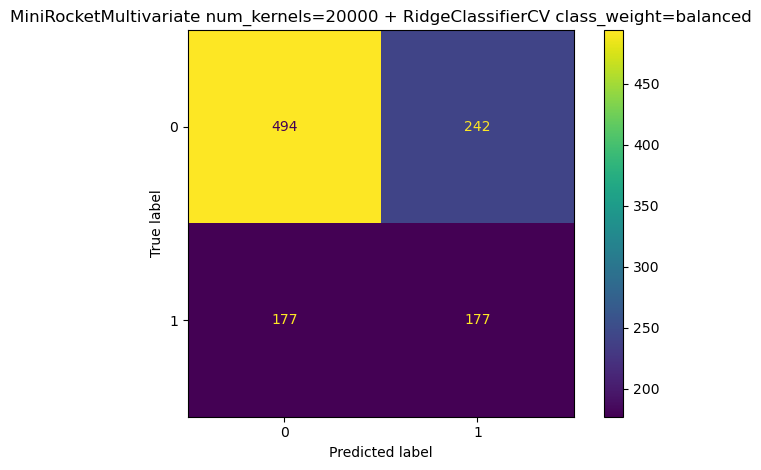

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc
0,MiniRocketMultivariate num_kernels=20000 + Rid...,0.615596,0.585598,0.579324,0.585598,0.58008,0.634308,0.615596,0.622879,0.631698


In [34]:
# ============================================================
# Restore best previous MiniRocket configuration
# Full-resolution subject-scaled data
# Final model: num_kernels=20000, no scaling, class_weight="balanced"
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score
)
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Fixed final configuration from previous CV
# ------------------------------------------------------------
best_num_kernels = 20000
best_scaler_type = "none"
best_class_weight = "balanced"

print("=" * 90)
print("Refitting selected MiniRocket model on full training set")
print(f"num_kernels = {best_num_kernels}")
print(f"scaler_type = {best_scaler_type}")
print(f"class_weight = {best_class_weight}")
print("Final prediction uses the default RidgeClassifierCV threshold.")
print("=" * 90)

# ------------------------------------------------------------
# Fit MiniRocket only on the full training set
# ------------------------------------------------------------
final_minirocket_transformer = make_minirocket_transformer(
    num_kernels=best_num_kernels,
    random_state=random_state
)

X_train_minirocket_feat = final_minirocket_transformer.fit_transform(
    X_train_minirocket,
    y_train
)

X_test_minirocket_feat = final_minirocket_transformer.transform(
    X_test_minirocket
)

print("MiniRocket feature matrix - train:", X_train_minirocket_feat.shape)
print("MiniRocket feature matrix - test:", X_test_minirocket_feat.shape)

# ------------------------------------------------------------
# No scaling for the selected configuration
# ------------------------------------------------------------
final_minirocket_scaler = None

# ------------------------------------------------------------
# Fit final Ridge classifier
# ------------------------------------------------------------
final_minirocket_classifier = RidgeClassifierCV(
    alphas=np.logspace(-3, 3, 10),
    class_weight=best_class_weight
)

final_minirocket_classifier.fit(
    X_train_minirocket_feat,
    y_train
)

# ------------------------------------------------------------
# Predict on test set with default threshold
# ------------------------------------------------------------
y_score_best_minirocket = final_minirocket_classifier.decision_function(
    X_test_minirocket_feat
)

y_pred_best_minirocket = final_minirocket_classifier.predict(
    X_test_minirocket_feat
)

# ------------------------------------------------------------
# Final evaluation
# ------------------------------------------------------------
print("\n" + "=" * 90)
print("Final MiniRocket test performance")
print("=" * 90)

print(f"Accuracy: {accuracy_score(y_test, y_pred_best_minirocket):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_best_minirocket):.4f}")
print(classification_report(y_test, y_pred_best_minirocket))

minirocket_test_results = evaluate_classifier(
    model_name=(
        "MiniRocketMultivariate num_kernels=20000 "
        "+ RidgeClassifierCV class_weight=balanced"
    ),
    y_true=y_test,
    y_pred=y_pred_best_minirocket,
    y_score=y_score_best_minirocket,
    show_confusion_matrix=True
)

display(pd.DataFrame([minirocket_test_results]))